Linear Regression Mean Squared Error: 35866.58003296702
Random Forest Mean Squared Error: 15959753.11278379
Decision Tree Mean Squared Error: 16036374.878611714
SVM Mean Squared Error: 120869537.53590912
ANN Mean Squared Error: 15587644.754783139


C:\Users\shamg\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


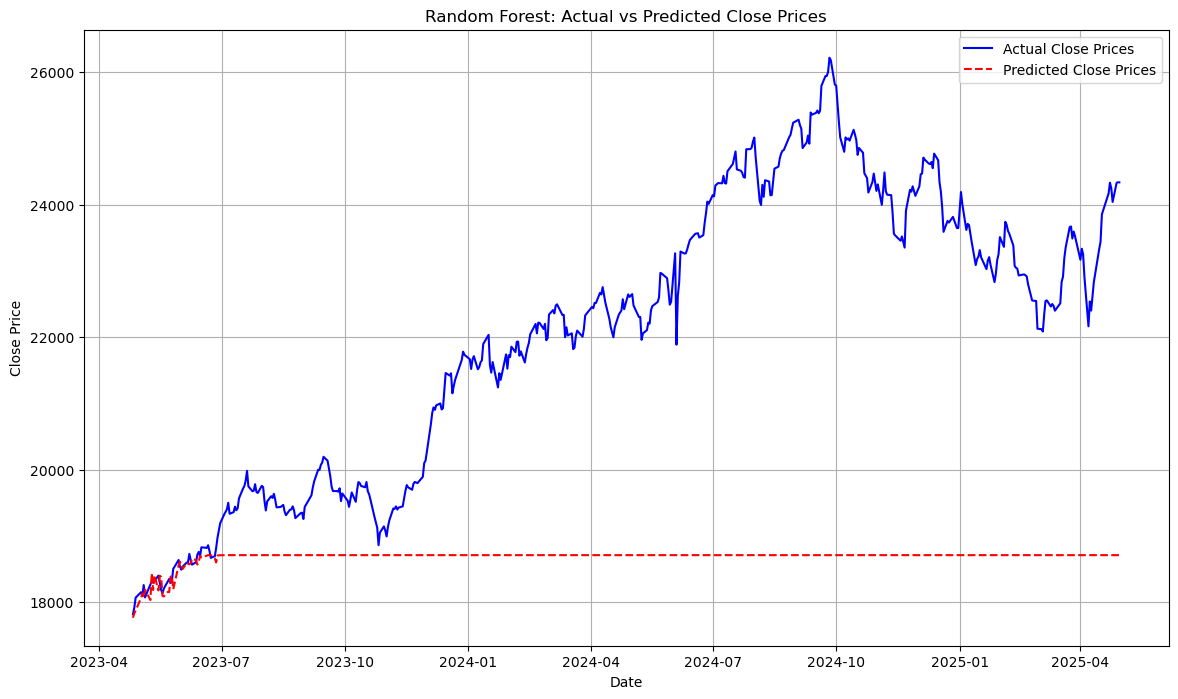

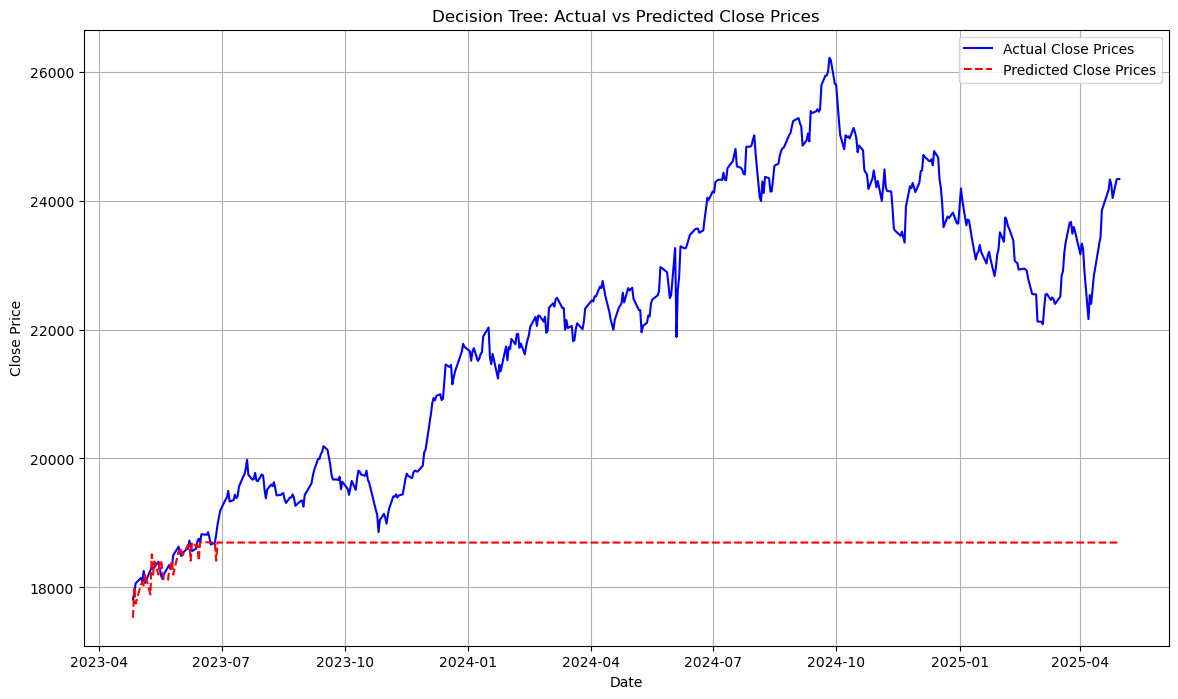

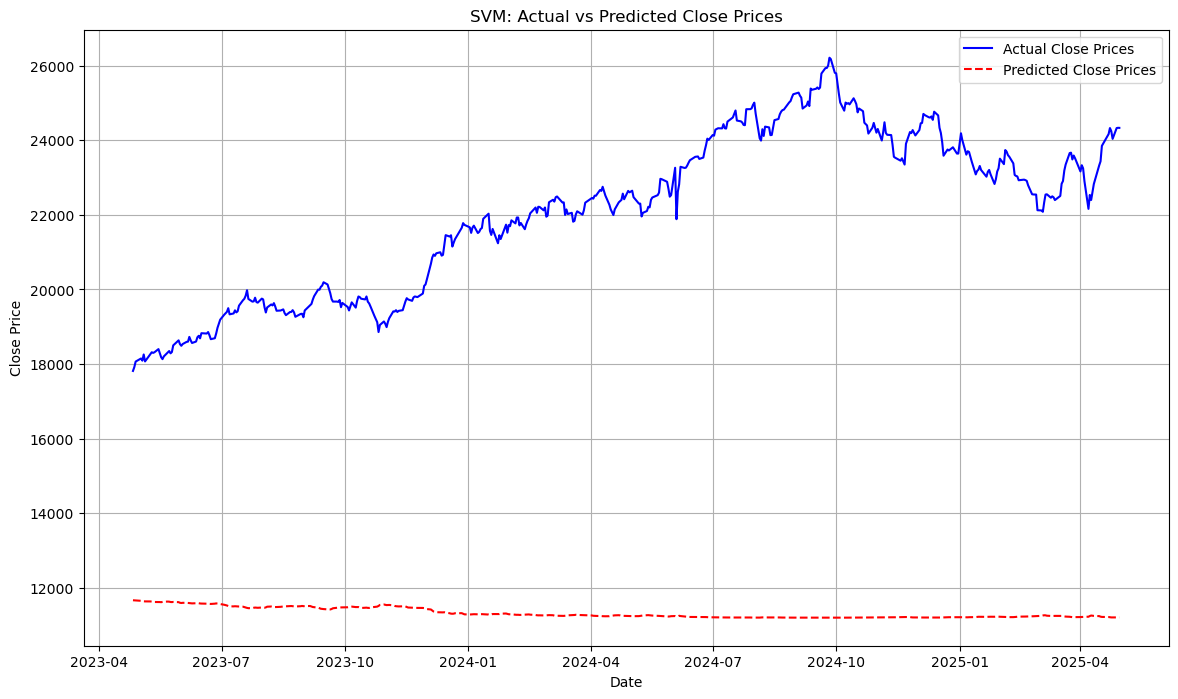

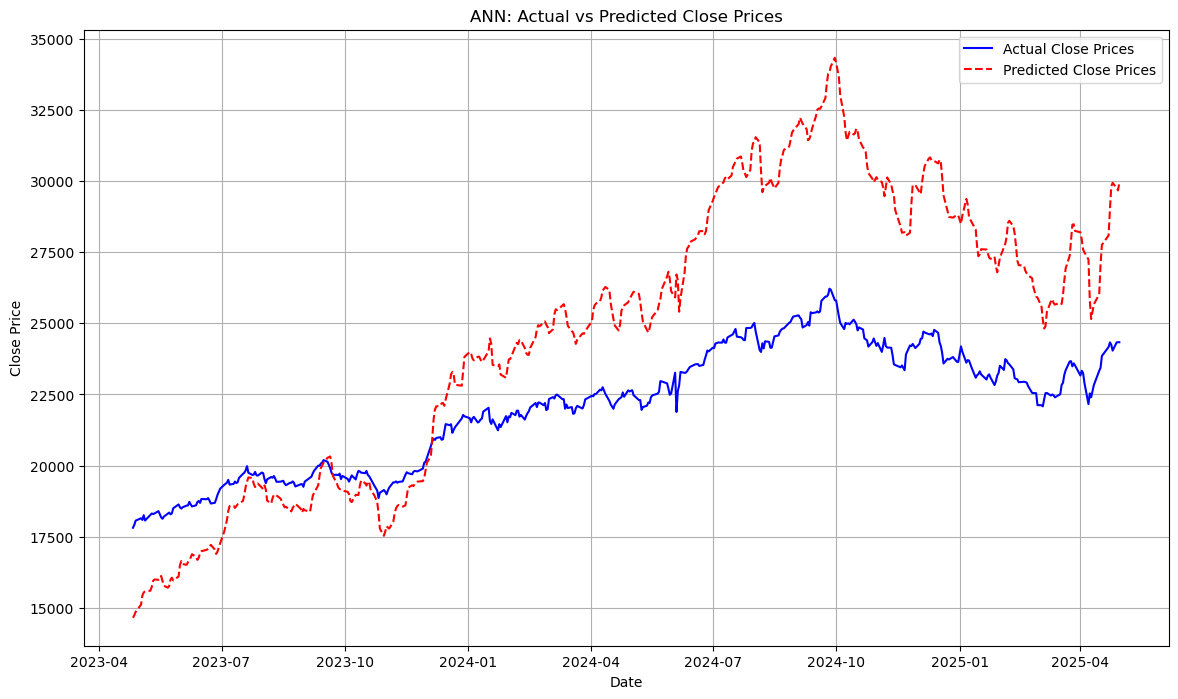

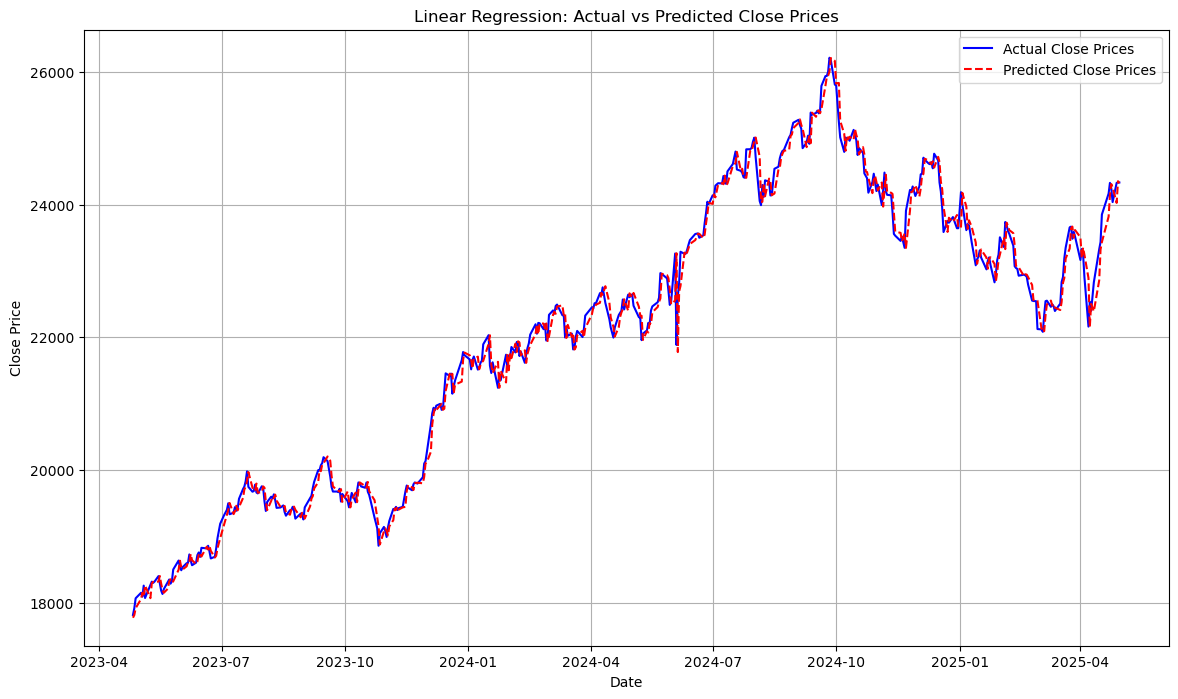

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = r"D:\College & Work Downloads\combined_dataset.csv"
data = pd.read_csv(file_path)

# Convert the 'Date' column to datetime and set it as the index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Create lagged features for the specified columns
for column in ['Open_NIFTY', 'High_NIFTY', 'Low_NIFTY', 'Close_x']:
    data[f'{column}_Lag1'] = data[column].shift(1)
    data[f'{column}_Lag2'] = data[column].shift(2)

# Drop rows with missing values
data.dropna(inplace=True)

# Define features and target variable
features = [f'{col}_Lag1' for col in ['Open_NIFTY', 'High_NIFTY', 'Low_NIFTY', 'Close_x']] + \
           [f'{col}_Lag2' for col in ['Open_NIFTY', 'High_NIFTY', 'Low_NIFTY', 'Close_x']]
X = data[features]
y = data['Close_x']  # Target variable is 'Close_x'

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_predictions)
print(f'Linear Regression Mean Squared Error: {lr_mse}')

# Train a Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_mse = mean_squared_error(y_test, rf_predictions)
print(f'Random Forest Mean Squared Error: {rf_mse}')

# Train a Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_predictions = dt_model.predict(X_test_scaled)
dt_mse = mean_squared_error(y_test, dt_predictions)
print(f'Decision Tree Mean Squared Error: {dt_mse}')

# Train an SVM model
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_model.fit(X_train_scaled, y_train)
svm_predictions = svm_model.predict(X_test_scaled)
svm_mse = mean_squared_error(y_test, svm_predictions)
print(f'SVM Mean Squared Error: {svm_mse}')

# Train an Artificial Neural Network model
ann_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)
ann_predictions = ann_model.predict(X_test_scaled)
ann_mse = mean_squared_error(y_test, ann_predictions)
print(f'ANN Mean Squared Error: {ann_mse}')

# Plot the actual vs predicted values for each model
def plot_predictions(y_test, predictions, title):
    plt.figure(figsize=(14, 8))
    plt.plot(y_test.index, y_test, label='Actual Close Prices', color='blue')
    plt.plot(y_test.index, predictions, label='Predicted Close Prices', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid()
    plt.show()

plot_predictions(y_test, rf_predictions, 'Random Forest: Actual vs Predicted Close Prices')
plot_predictions(y_test, dt_predictions, 'Decision Tree: Actual vs Predicted Close Prices')
plot_predictions(y_test, svm_predictions, 'SVM: Actual vs Predicted Close Prices')
plot_predictions(y_test, ann_predictions, 'ANN: Actual vs Predicted Close Prices')
plot_predictions(y_test, lr_predictions, 'Linear Regression: Actual vs Predicted Close Prices')

Model Performance (Mean Squared Error):

Model                            MSE
----------------------------------------
Random Forest             15959753.1128
Decision Tree             16036374.8786
SVM                       120869537.5359
ANN                       15587644.7548
Linear Regression         35866.5800


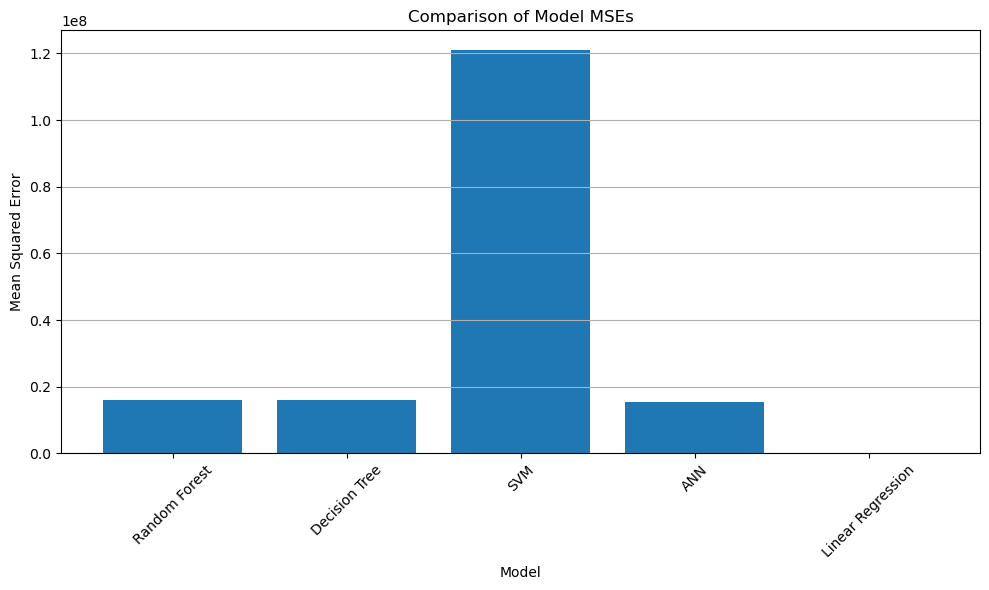

In [7]:
import numpy as np

# Create a dictionary of model names and their MSE values
mse_scores = {
    'Random Forest': rf_mse,
    'Decision Tree': dt_mse,
    'SVM': svm_mse,
    'ANN': ann_mse,
    'Linear Regression': lr_mse
}

# Print the results in a table format
print("Model Performance (Mean Squared Error):\n")
print("{:<25} {:>10}".format("Model", "MSE"))
print("-" * 40)
for model, mse in mse_scores.items():
    print("{:<25} {:>10.4f}".format(model, mse))

# Optional: Plotting the MSEs
plt.figure(figsize=(10, 6))
plt.bar(mse_scores.keys(), mse_scores.values())
plt.title("Comparison of Model MSEs")
plt.xlabel("Model")
plt.ylabel("Mean Squared Error")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import r2_score

# Calculate R² for each model
r2_scores = {
    'Random Forest': r2_score(y_test, rf_predictions),
    'Decision Tree': r2_score(y_test, dt_predictions),
    'SVM': r2_score(y_test, svm_predictions),
    'ANN': r2_score(y_test, ann_predictions),
    'Linear Regression': r2_score(y_test, lr_predictions)
}

# Print R² results in table format
print("\nModel Performance (R² Score):\n")
print("{:<25} {:>10}".format("Model", "R² Score"))
print("-" * 40)
for model, r2 in r2_scores.items():
    print("{:<25} {:>10.4f}".format(model, r2))



Model Performance (R² Score):

Model                       R² Score
----------------------------------------
Random Forest                -2.4246
Decision Tree                -2.4410
SVM                         -24.9358
ANN                          -2.3447
Linear Regression             0.9923
